In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
forest_fires = fetch_ucirepo(id=162) 
  
# data (as pandas dataframes) 
X = forest_fires.data.features 
y = forest_fires.data.targets 
  
# metadata 
print(forest_fires.metadata) 
  
# variable information 
print(forest_fires.variables) 


{'uci_id': 162, 'name': 'Forest Fires', 'repository_url': 'https://archive.ics.uci.edu/dataset/162/forest+fires', 'data_url': 'https://archive.ics.uci.edu/static/public/162/data.csv', 'abstract': 'This is a difficult regression task, where the aim is to predict the burned area of forest fires, in the northeast region of Portugal, by using meteorological and other data (see details at: http://www.dsi.uminho.pt/~pcortez/forestfires).', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 517, 'num_features': 12, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['area'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2007, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5D88D', 'creators': ['Paulo Cortez', 'Anbal Morais'], 'intro_paper': {'ID': 368, 'type': 'NATIVE', 'title': 'A data mining approach to predict forest fires using meteorological da

In [4]:
X

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [5]:
X.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64

In [6]:
X.dtypes

X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
dtype: object

In [7]:
df=pd.concat([X,y],axis=1)
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [8]:
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
             'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}

day_map = {'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5, 'sat':6, 'sun':7}

df['month'] = df['month'].map(month_map)
df['day'] = df['day'].map(day_map)


In [9]:
# Encode month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Encode day (7 ngày/tuần)
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)

In [10]:
df.dtypes

X              int64
Y              int64
month          int64
day            int64
FFMC         float64
DMC          float64
DC           float64
ISI          float64
temp         float64
RH             int64
wind         float64
rain         float64
area         float64
month_sin    float64
month_cos    float64
day_sin      float64
day_cos      float64
dtype: object

In [11]:
df['log_area'] = np.log(df['area'] + 1)

In [12]:
if 'log_area' not in df.columns:
    df['log_area'] = np.log(df['area']+ 1)

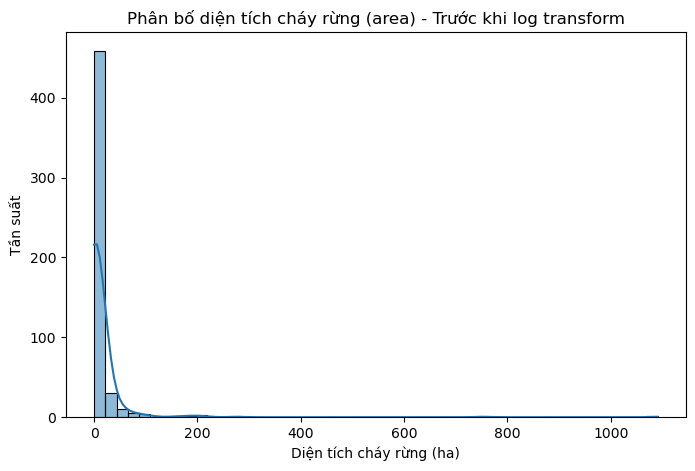

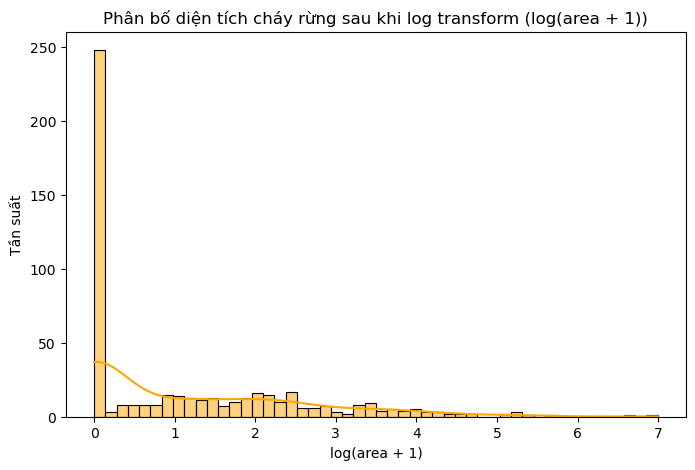

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=50, kde=True)
plt.title("Phân bố diện tích cháy rừng (area) - Trước khi log transform")
plt.xlabel("Diện tích cháy rừng (ha)")
plt.ylabel("Tần suất")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['log_area'], bins=50 , kde=True,color='orange')
plt.title("Phân bố diện tích cháy rừng sau khi log transform (log(area + 1))")
plt.xlabel("log(area + 1)")
plt.ylabel("Tần suất")
plt.show()

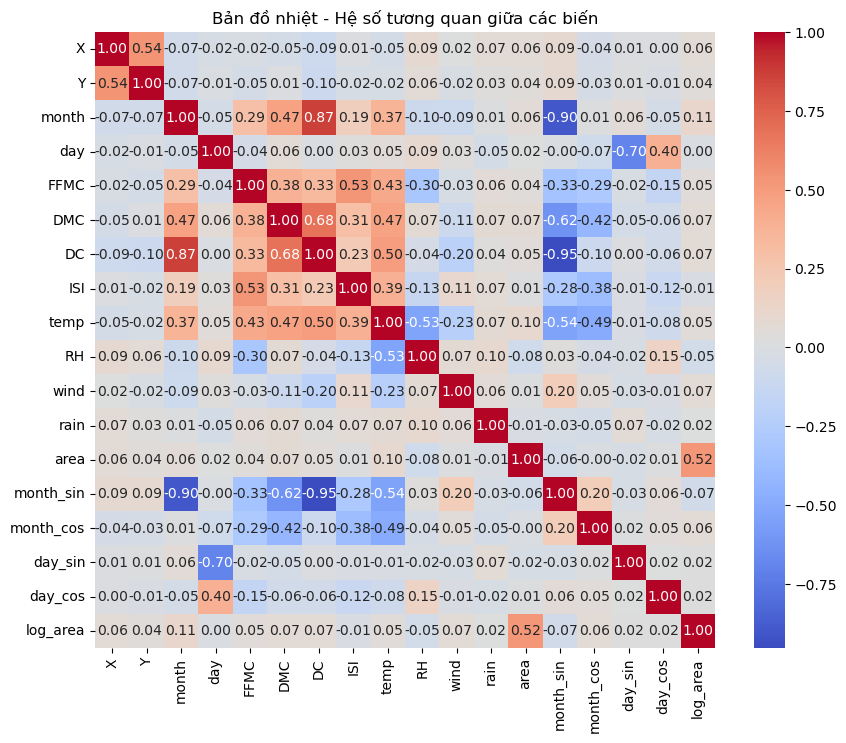

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Bản đồ nhiệt - Hệ số tương quan giữa các biến")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_16100\582848319.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='month', y='log_area', palette='Set2', estimator='mean')


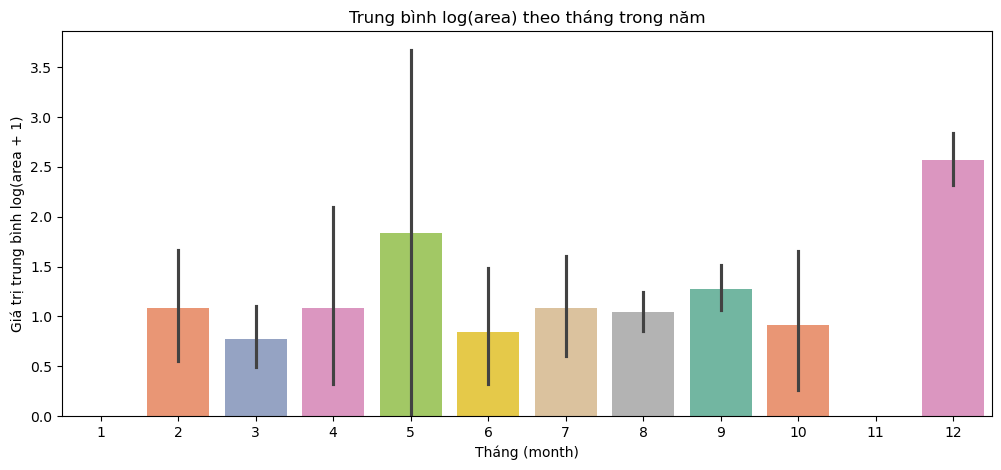

C:\Users\Admin\AppData\Local\Temp\ipykernel_16100\582848319.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day', y='log_area', palette='Set3', estimator='mean')


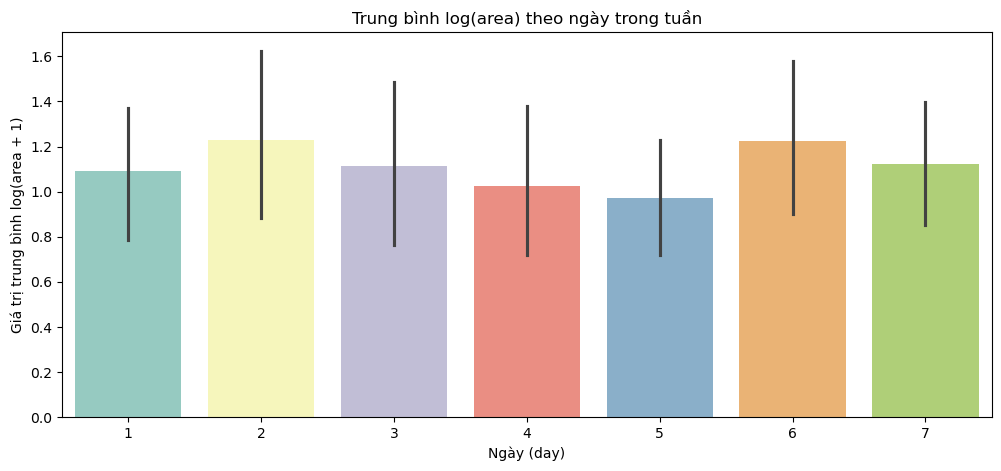

In [15]:
# Trung bình log(area) theo tháng
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='month', y='log_area', palette='Set2', estimator='mean')
plt.title("Trung bình log(area) theo tháng trong năm")
plt.xlabel("Tháng (month)")
plt.ylabel("Giá trị trung bình log(area + 1)")
plt.show()

# Trung bình log(area) theo ngày
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='day', y='log_area', palette='Set3', estimator='mean')
plt.title("Trung bình log(area) theo ngày trong tuần")
plt.xlabel("Ngày (day)")
plt.ylabel("Giá trị trung bình log(area + 1)")
plt.show()

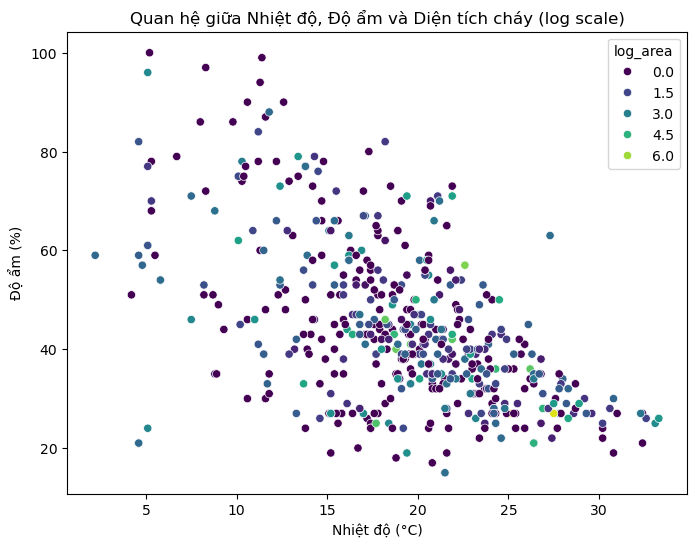

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='temp', y='RH', hue='log_area', data=df, palette='viridis')
plt.title("Quan hệ giữa Nhiệt độ, Độ ẩm và Diện tích cháy (log scale)")
plt.xlabel("Nhiệt độ (°C)")
plt.ylabel("Độ ẩm (%)")
plt.show()

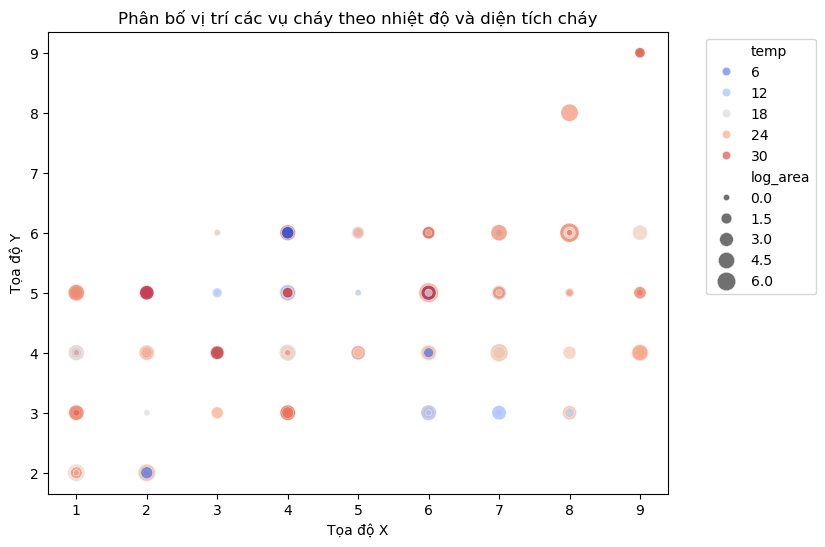

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='X', y='Y', size='log_area', hue='temp',
                data=df, sizes=(20, 200), alpha=0.7, palette='coolwarm')
plt.title("Phân bố vị trí các vụ cháy theo nhiệt độ và diện tích cháy")
plt.xlabel("Tọa độ X")
plt.ylabel("Tọa độ Y")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [18]:
df.drop(['month', 'day', 'area'], axis=1)

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos,log_area
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,1.000000,6.123234e-17,-9.749279e-01,-0.222521,0.000000
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,-0.866025,5.000000e-01,9.749279e-01,-0.222521,0.000000
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,-0.866025,5.000000e-01,-7.818315e-01,0.623490,0.000000
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,1.000000,6.123234e-17,-9.749279e-01,-0.222521,0.000000
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,1.000000,6.123234e-17,-2.449294e-16,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,2.006871
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,4.012592
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,2.498152
515,1,4,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,-0.866025,-5.000000e-01,-7.818315e-01,0.623490,0.000000


In [19]:
feature = df.drop(columns=['log_area'])
target = df['log_area']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler trên tập huấn luyện
X_train_scaled = scaler.fit_transform(X_train)

# Áp dụng transform cho tập kiểm tra
X_test_scaled = scaler.transform(X_test)


In [22]:
val_train_df = pd.DataFrame(X_train_scaled, columns=scaler.get_feature_names_out(),index= X_train.index)
val_train_df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_sin,month_cos,day_sin,day_cos
329,-0.288472,-1.094859,0.669844,0.843134,0.280286,-0.150282,0.810272,-0.095838,0.797602,-1.059419,0.001631,-0.067817,-0.171087,-0.649665,0.531731,-1.043826,0.713422
173,-0.288472,-0.266696,0.669844,-1.532134,0.061652,0.217866,0.549136,-0.455434,-0.205272,-0.335215,-1.008923,-0.067817,-0.176789,-0.649665,0.531731,1.164342,0.713422
272,-1.161285,0.561466,0.230026,-1.057080,0.263468,0.614919,0.435442,1.419602,0.227001,0.147588,0.001631,-0.067817,-0.176350,-0.458609,-0.698566,1.437028,-0.507633
497,-0.724878,-0.266696,0.230026,-1.057080,0.936186,1.048482,0.487669,1.419602,2.319206,-1.059419,-1.008923,-0.067817,0.077799,-0.458609,-0.698566,1.437028,-0.507633
182,0.147934,-0.266696,-2.408881,1.318187,-0.627884,-1.469227,-2.014816,-1.251682,-1.121692,0.509690,-1.008923,-0.067817,-0.104206,2.011400,1.762028,0.060258,1.256843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-0.288472,0.561466,0.669844,0.368080,0.633463,-0.411941,0.572437,1.830569,-0.205272,-0.455916,-0.222936,-0.067817,-0.244108,-0.649665,0.531731,-1.316512,-0.507633
106,-0.288472,0.561466,-1.969064,-0.106973,0.145742,-1.239514,-1.910361,-0.327007,-0.118818,-0.938719,-0.503646,-0.067817,-0.244108,2.202456,0.531731,-0.552462,-1.486843
270,-1.161285,-1.923022,0.230026,-1.057080,0.263468,0.614919,0.435442,1.419602,0.503656,0.690741,-0.503646,-0.067817,-0.232706,-0.458609,-0.698566,1.437028,-0.507633
435,-1.161285,0.561466,-0.209792,0.843134,0.044834,-0.418026,-0.695879,-0.815030,0.849475,0.388990,-1.233490,-0.067817,-0.244108,0.063366,-1.599206,-1.043826,0.713422


In [23]:
val_test_df = pd.DataFrame(X_test_scaled, columns=scaler.get_feature_names_out(),index= X_test.index)
val_test_df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_sin,month_cos,day_sin,day_cos
304,0.584341,0.561466,-1.089428,0.843134,-0.913789,-1.280589,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817,-0.244108,1.489426,-1.599206,-1.043826,0.713422
501,1.020747,0.561466,0.230026,-1.057080,0.936186,1.048482,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824,-0.244108,-0.458609,-0.698566,1.437028,-0.507633
441,1.457153,1.389629,0.230026,-1.532134,0.263468,1.442492,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817,-0.217137,-0.458609,-0.698566,1.164342,0.713422
153,0.147934,-0.266696,0.669844,0.368080,0.633463,-0.411941,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817,-0.212093,-0.649665,0.531731,-1.316512,-0.507633
503,-1.161285,-0.266696,0.230026,-0.582027,0.667098,0.414111,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817,-0.201348,-0.458609,-0.698566,0.672978,-1.486843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0.584341,0.561466,0.230026,-0.582027,0.919368,0.226994,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817,-0.189068,-0.458609,-0.698566,0.672978,-1.486843
275,-0.288472,1.389629,1.989297,-0.106973,-0.997879,-1.304929,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817,-0.126134,0.776396,2.992325,-0.552462,-1.486843
509,0.147934,-0.266696,0.230026,0.368080,0.078470,0.832461,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054,-0.196524,-0.458609,-0.698566,-1.316512,-0.507633
513,-1.161285,-0.266696,0.230026,1.318187,-1.502417,-0.843983,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817,0.946377,-0.458609,-0.698566,0.060258,1.256843


In [24]:
from sklearn.linear_model import LinearRegression

# Khởi tạo mô hình hồi quy tuyến tính
lin_reg = LinearRegression()


In [25]:
lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [26]:
k=lin_reg.predict(X_test_scaled)

In [27]:
from sklearn.metrics import r2_score 
r2_score(y_test, k )

-0.268265353178067

In [28]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y_test, k)

2.787471683373367

In [29]:
from sklearn.ensemble import RandomForestRegressor
oneclass_svm = RandomForestRegressor(
    n_estimators= 400,
    random_state=42
)

# Huấn luyện mô hình (fit unsupervised)
oneclass_svm.fit(val_train_df, y_train)

RandomForestRegressor(n_estimators=400, random_state=42)

In [30]:
y_pred = oneclass_svm.predict(val_test_df)

In [31]:
r2_score(y_test,y_pred)

0.9904765913575048

In [32]:
mean_squared_error(y_test,y_pred)

0.02093113389372984

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR

In [34]:
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Dò tham số bằng 5-fold cross validation
grid = GridSearchCV(SVR(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}


In [35]:
best_params = grid.best_params_

svr_best = SVR(
    kernel=best_params['kernel'],
    C=best_params['C'],
    epsilon=best_params['epsilon']
)

svr_best.fit(X_train_scaled, y_train)

SVR(C=10)

In [36]:
y_pred = svr_best.predict(X_test_scaled)

# Đánh giá độ chính xác
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nSVR Model Evaluation")
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))



SVR Model Evaluation
RMSE: 0.9692
R²: 0.5726


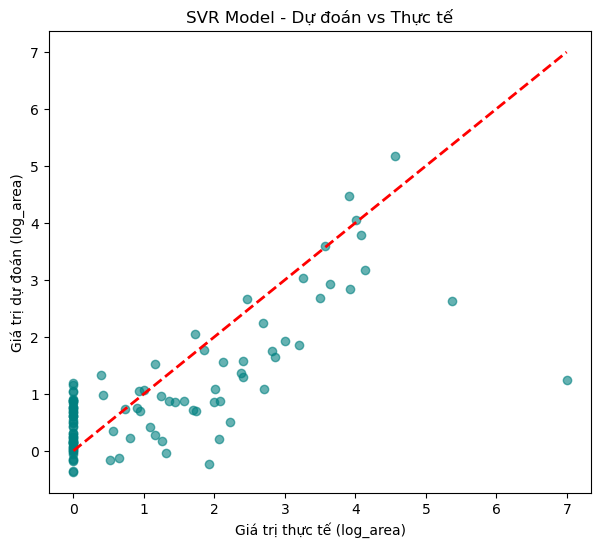

In [37]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Giá trị thực tế (log_area)")
plt.ylabel("Giá trị dự đoán (log_area)")
plt.title("SVR Model - Dự đoán vs Thực tế")
plt.show()


In [38]:
df1=df.copy()
df1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_sin,month_cos,day_sin,day_cos,log_area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00,1.000000,6.123234e-17,-9.749279e-01,-0.222521,0.000000
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00,-0.866025,5.000000e-01,9.749279e-01,-0.222521,0.000000
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00,-0.866025,5.000000e-01,-7.818315e-01,0.623490,0.000000
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00,1.000000,6.123234e-17,-9.749279e-01,-0.222521,0.000000
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00,1.000000,6.123234e-17,-2.449294e-16,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,8,7,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,2.006871
513,2,4,8,7,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,4.012592
514,7,4,8,7,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,2.498152
515,1,4,8,6,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,-0.866025,-5.000000e-01,-7.818315e-01,0.623490,0.000000


In [39]:
df1['log_area'] = np.log(df1['area'] + 1)

In [40]:
df1_1=df1.drop('area',axis=1)
df1_1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos,log_area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,1.000000,6.123234e-17,-9.749279e-01,-0.222521,0.000000
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,-0.866025,5.000000e-01,9.749279e-01,-0.222521,0.000000
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,-0.866025,5.000000e-01,-7.818315e-01,0.623490,0.000000
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,1.000000,6.123234e-17,-9.749279e-01,-0.222521,0.000000
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,1.000000,6.123234e-17,-2.449294e-16,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,8,7,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,2.006871
513,2,4,8,7,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,4.012592
514,7,4,8,7,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,-0.866025,-5.000000e-01,-2.449294e-16,1.000000,2.498152
515,1,4,8,6,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,-0.866025,-5.000000e-01,-7.818315e-01,0.623490,0.000000


In [41]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df1_1['season'] = df1_1['month'].map(month_to_season)

In [42]:
X1 =df1_1.drop(['log_area'], axis=1)

In [43]:
y1 = df1_1['log_area']

In [44]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [45]:
from sklearn.preprocessing import OneHotEncoder
encode_data_train=X1_train[['month', 'day', 'season']]
encoder = OneHotEncoder()
encoded = encoder.fit_transform(encode_data_train)

encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1239 stored elements and shape (413, 23)>

In [46]:
train1_df = pd.DataFrame.sparse.from_spmatrix(encoded, columns=encoder.get_feature_names_out(),index= X_train.index)
train1_df

,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,day_2,day_3,day_4,day_5,day_6,day_7,season_Autumn,season_Spring,season_Summer,season_Winter
329,0,0,0,0,0,0,0,0,1.0,0,...,0,0,0,0,1.0,0,1.0,0,0,0
173,0,0,0,0,0,0,0,0,1.0,0,...,0,0,0,0,0,0,1.0,0,0,0
272,0,0,0,0,0,0,0,1.0,0,0,...,1.0,0,0,0,0,0,0,0,1.0,0
497,0,0,0,0,0,0,0,1.0,0,0,...,1.0,0,0,0,0,0,0,0,1.0,0
182,0,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,1.0,0,...,0,0,0,1.0,0,0,1.0,0,0,0
106,0,0,1.0,0,0,0,0,0,0,0,...,0,0,1.0,0,0,0,0,1.0,0,0
270,0,0,0,0,0,0,0,1.0,0,0,...,1.0,0,0,0,0,0,0,0,1.0,0
435,0,0,0,0,0,0,1.0,0,0,0,...,0,0,0,0,1.0,0,0,0,1.0,0


In [47]:
encode_test=encoder.transform(X1_test[['month', 'day', 'season']])
encode_test_df=pd.DataFrame.sparse.from_spmatrix(encode_test, columns=encoder.get_feature_names_out(['month', 'day', 'season']),index=X1_test.index)

In [48]:
from sklearn.preprocessing import StandardScaler
scale_train_data=X1_train.drop(['month', 'day', 'season'],axis=1)
scaler1 = StandardScaler()

# Fit scaler trên tập huấn luyện
X1_train_scaled = scaler1.fit_transform(scale_train_data)

# Áp dụng transform cho tập kiểm tra
scale_test_data=X1_test.drop(['month', 'day', 'season'],axis=1)
X1_test_scaled = scaler1.transform(scale_test_data)

In [49]:
train2_df = pd.DataFrame(X1_train_scaled, columns=scaler1.get_feature_names_out(),index= X_train.index)
train2_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos
329,-0.288472,-1.094859,0.280286,-0.150282,0.810272,-0.095838,0.797602,-1.059419,0.001631,-0.067817,-0.649665,0.531731,-1.043826,0.713422
173,-0.288472,-0.266696,0.061652,0.217866,0.549136,-0.455434,-0.205272,-0.335215,-1.008923,-0.067817,-0.649665,0.531731,1.164342,0.713422
272,-1.161285,0.561466,0.263468,0.614919,0.435442,1.419602,0.227001,0.147588,0.001631,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
497,-0.724878,-0.266696,0.936186,1.048482,0.487669,1.419602,2.319206,-1.059419,-1.008923,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
182,0.147934,-0.266696,-0.627884,-1.469227,-2.014816,-1.251682,-1.121692,0.509690,-1.008923,-0.067817,2.011400,1.762028,0.060258,1.256843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-0.288472,0.561466,0.633463,-0.411941,0.572437,1.830569,-0.205272,-0.455916,-0.222936,-0.067817,-0.649665,0.531731,-1.316512,-0.507633
106,-0.288472,0.561466,0.145742,-1.239514,-1.910361,-0.327007,-0.118818,-0.938719,-0.503646,-0.067817,2.202456,0.531731,-0.552462,-1.486843
270,-1.161285,-1.923022,0.263468,0.614919,0.435442,1.419602,0.503656,0.690741,-0.503646,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
435,-1.161285,0.561466,0.044834,-0.418026,-0.695879,-0.815030,0.849475,0.388990,-1.233490,-0.067817,0.063366,-1.599206,-1.043826,0.713422


In [50]:
test2_df = pd.DataFrame(X1_test_scaled, columns=scaler1.get_feature_names_out(),index= X_test.index)
test2_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos
304,0.584341,0.561466,-0.913789,-1.280589,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817,1.489426,-1.599206,-1.043826,0.713422
501,1.020747,0.561466,0.936186,1.048482,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824,-0.458609,-0.698566,1.437028,-0.507633
441,1.457153,1.389629,0.263468,1.442492,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817,-0.458609,-0.698566,1.164342,0.713422
153,0.147934,-0.266696,0.633463,-0.411941,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817,-0.649665,0.531731,-1.316512,-0.507633
503,-1.161285,-0.266696,0.667098,0.414111,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817,-0.458609,-0.698566,0.672978,-1.486843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0.584341,0.561466,0.919368,0.226994,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817,-0.458609,-0.698566,0.672978,-1.486843
275,-0.288472,1.389629,-0.997879,-1.304929,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817,0.776396,2.992325,-0.552462,-1.486843
509,0.147934,-0.266696,0.078470,0.832461,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054,-0.458609,-0.698566,-1.316512,-0.507633
513,-1.161285,-0.266696,-1.502417,-0.843983,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817,-0.458609,-0.698566,0.060258,1.256843


In [51]:
final_df=pd.concat([encode_test_df,test2_df],axis=1,join='inner')
final_df

,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos
304,0,0,0,0,1.0,0,0,0,0,0,...,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817,1.489426,-1.599206,-1.043826,0.713422
501,0,0,0,0,0,0,0,1.0,0,0,...,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824,-0.458609,-0.698566,1.437028,-0.507633
441,0,0,0,0,0,0,0,1.0,0,0,...,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817,-0.458609,-0.698566,1.164342,0.713422
153,0,0,0,0,0,0,0,0,1.0,0,...,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817,-0.649665,0.531731,-1.316512,-0.507633
503,0,0,0,0,0,0,0,1.0,0,0,...,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817,-0.458609,-0.698566,0.672978,-1.486843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0,0,0,0,0,0,0,1.0,0,0,...,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817,-0.458609,-0.698566,0.672978,-1.486843
275,0,0,0,0,0,0,0,0,0,0,...,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817,0.776396,2.992325,-0.552462,-1.486843
509,0,0,0,0,0,0,0,1.0,0,0,...,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054,-0.458609,-0.698566,-1.316512,-0.507633
513,0,0,0,0,0,0,0,1.0,0,0,...,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817,-0.458609,-0.698566,0.060258,1.256843


In [52]:
finish_df=pd.concat([train1_df,train2_df],axis=1,join='inner')
finish_df

,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,...,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos
329,0,0,0,0,0,0,0,0,1.0,0,...,0.810272,-0.095838,0.797602,-1.059419,0.001631,-0.067817,-0.649665,0.531731,-1.043826,0.713422
173,0,0,0,0,0,0,0,0,1.0,0,...,0.549136,-0.455434,-0.205272,-0.335215,-1.008923,-0.067817,-0.649665,0.531731,1.164342,0.713422
272,0,0,0,0,0,0,0,1.0,0,0,...,0.435442,1.419602,0.227001,0.147588,0.001631,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
497,0,0,0,0,0,0,0,1.0,0,0,...,0.487669,1.419602,2.319206,-1.059419,-1.008923,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
182,0,1.0,0,0,0,0,0,0,0,0,...,-2.014816,-1.251682,-1.121692,0.509690,-1.008923,-0.067817,2.011400,1.762028,0.060258,1.256843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,1.0,0,...,0.572437,1.830569,-0.205272,-0.455916,-0.222936,-0.067817,-0.649665,0.531731,-1.316512,-0.507633
106,0,0,1.0,0,0,0,0,0,0,0,...,-1.910361,-0.327007,-0.118818,-0.938719,-0.503646,-0.067817,2.202456,0.531731,-0.552462,-1.486843
270,0,0,0,0,0,0,0,1.0,0,0,...,0.435442,1.419602,0.503656,0.690741,-0.503646,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
435,0,0,0,0,0,0,1.0,0,0,0,...,-0.695879,-0.815030,0.849475,0.388990,-1.233490,-0.067817,0.063366,-1.599206,-1.043826,0.713422


In [53]:
lin_reg1 = LinearRegression()

In [54]:
lin_reg1.fit(finish_df, y1_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


LinearRegression()

In [55]:
k1=lin_reg1.predict(final_df)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [56]:
r2_score(y1_test, k1 )

-0.047159971473460294

In [57]:
mean_squared_error(y1_test, k)

2.787471683373367

In [58]:
svr1 = SVR(kernel='rbf',C=0.1,epsilon=1)  # hoặc thử 'linear', 'poly'
svr1.fit(finish_df, y1_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


SVR(C=0.1, epsilon=1)

In [59]:
param_grid1 = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid1 = GridSearchCV(SVR(), param_grid, cv=5)
grid1.fit(finish_df, y1_train)

print("Best params:", grid.best_params_)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\s

Best params: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}


In [60]:
val_pre=svr1.predict(final_df)
val_pre

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([1.00829412, 0.99253095, 1.02138005, 0.99895179, 0.99776095,
       1.00912214, 1.01544917, 0.99401075, 1.01586624, 1.0132068 ,
       1.00809918, 1.01213927, 1.035627  , 0.98449524, 1.02592097,
       1.02042089, 1.02642539, 0.97681352, 1.00152141, 0.99837083,
       1.01777665, 0.97654165, 1.28163094, 1.00030712, 1.00389525,
       1.01877429, 1.0191591 , 1.01778352, 1.00791131, 1.04049784,
       1.01742054, 1.00043851, 1.06005295, 1.00681695, 1.00737681,
       1.00697608, 0.99967856, 1.00532289, 1.00941075, 0.98227365,
       1.06781578, 1.00035163, 0.99014103, 1.00334287, 1.05769956,
       1.02210661, 0.97729258, 1.02261834, 0.98847913, 1.01976191,
       1.00644761, 1.00092646, 1.03394444, 0.99068309, 0.99069262,
       1.0019207 , 1.0075619 , 1.04441282, 1.00743073, 1.01038425,
       1.01684401, 1.01158303, 0.98917417, 1.00198763, 0.99859371,
       1.04485899, 0.97939529, 1.06872957, 1.01406821, 1.05344577,
       1.00887649, 1.02390527, 1.0404421 , 1.06042844, 1.00623

In [61]:
r2_score(y1_test,val_pre)

-0.0001043125357533814

In [62]:
mean_squared_error(y1_test,val_pre)

2.198090836927241

In [63]:
rfr=RandomForestRegressor(n_estimators=100,random_state=0)

In [64]:
rfr.fit(finish_df,y1_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


RandomForestRegressor(random_state=0)

In [65]:
val_pre1=rfr.predict(final_df)
val_pre1

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([1.36593694, 0.55194017, 1.2237548 , 1.62790887, 0.80564944,
       0.42870809, 1.20763106, 0.91927867, 1.15049698, 0.94462699,
       1.22958544, 1.58739301, 0.76187399, 0.48624006, 1.00154749,
       1.06105764, 1.12331985, 0.89822236, 0.95245625, 0.83220107,
       0.76691709, 0.84932717, 2.27792944, 0.55228668, 1.0058379 ,
       1.0241171 , 1.08567571, 1.62296199, 2.02787084, 1.07818581,
       0.99427108, 1.57261338, 1.64612209, 1.00011106, 0.4366494 ,
       0.55927567, 1.20436279, 0.72520446, 1.48040118, 0.31521893,
       2.26343529, 0.37365973, 1.12749257, 1.1748117 , 1.91126568,
       1.6002978 , 1.00699611, 0.86602324, 0.63712983, 1.18306162,
       1.06908931, 1.14291544, 1.30748413, 0.2723576 , 0.86132849,
       0.93266702, 1.05968715, 1.05183435, 1.40235447, 1.32644448,
       0.60662611, 1.4834431 , 0.98433943, 0.71470444, 0.36595384,
       1.41911699, 0.71955231, 1.92703224, 1.59767422, 1.42470748,
       1.15758147, 1.90525569, 1.39595696, 0.7818625 , 0.57988

In [66]:
r2_score(y1_test,val_pre1)

-0.02829725980838793

In [67]:
mean_squared_error(y1_test,val_pre1)

2.2600550323508415

In [68]:
data=X
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [69]:
data1=data

<Axes: >

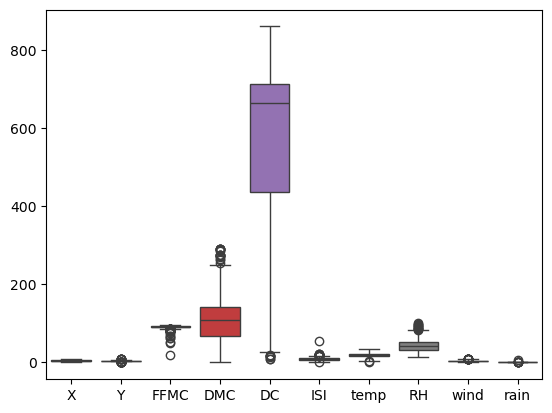

In [70]:
sns.boxplot(data1)

In [71]:
Q1_FFMC1=data1 ['FFMC'].quantile(0.25)
Q3_FFMC1=data1 ['FFMC'].quantile(0.75)
IQR_FFMC1=Q3_FFMC1-Q1_FFMC1
lower_FFMC1=Q1_FFMC1-1.5*IQR_FFMC1
upper_FFMC1=Q3_FFMC1+1.5*IQR_FFMC1
outlier1=data1[(data1['FFMC']<lower_FFMC1)|(data1['FFMC']>upper_FFMC1)]

In [72]:
Q1_DMC1=data1 ['DMC'].quantile(0.25)
Q3_DMC1=data1 ['DMC'].quantile(0.75)
IQR_DMC1=Q3_DMC1-Q1_DMC1
lower_DMC1=Q1_DMC1-1.5*IQR_DMC1
upper_DMC1=Q3_DMC1+1.5*IQR_DMC1
outlier2=data1[(data1['DMC']<lower_DMC1)|(data1['DMC']>upper_DMC1)]

In [73]:
Q1_ISI1=data1 ['ISI'].quantile(0.25)
Q3_ISI1=data1 ['ISI'].quantile(0.75)
IQR_ISI1=Q3_ISI1-Q1_ISI1
lower_ISI1=Q1_ISI1-1.5*IQR_ISI1
upper_ISI1=Q3_ISI1+1.5*IQR_ISI1
outlier3=data1[(data1['ISI']<lower_ISI1)|(data1['ISI']>upper_ISI1)]

In [74]:
Q1_RH1=data1 ['RH'].quantile(0.25)
Q3_RH1=data1 ['RH'].quantile(0.75)
IQR_RH1=Q3_RH1-Q1_RH1
lower_RH1=Q1_RH1-1.5*IQR_RH1
upper_RH1=Q3_RH1+1.5*IQR_RH1
outlier4=data1[(data1['RH']<lower_RH1)|(data1['RH']>upper_RH1)]

In [75]:
data1.loc[outlier1.index,'FFMC']=np.nan

In [76]:
data1.loc[outlier1.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
12,6,5,aug,fri,NaN,70.8,665.3,0.8,17.0,72,6.7,0.0
17,8,5,oct,mon,NaN,32.8,664.2,3.0,16.7,47,4.9,0.0
40,4,4,jul,tue,NaN,60.6,366.7,1.5,23.3,37,3.1,0.0
58,2,2,feb,mon,NaN,9.3,34.0,2.1,13.9,40,5.4,0.0
75,9,9,feb,thu,NaN,6.8,26.6,7.7,6.7,79,3.1,0.0
96,3,4,feb,sat,NaN,8.0,30.2,2.6,12.7,48,1.8,0.0
97,3,4,mar,sat,NaN,2.4,15.5,0.7,17.4,24,5.4,0.0
104,2,4,jan,sat,NaN,3.7,9.3,2.9,5.3,78,3.1,0.0
105,4,5,mar,fri,NaN,19.5,57.3,2.8,12.7,52,6.3,0.0
110,4,4,mar,fri,NaN,19.5,57.3,2.8,13.7,43,5.8,0.0


In [77]:
from sklearn.impute import SimpleImputer

In [78]:
imputer = SimpleImputer(strategy= 'mean', fill_value=np.nan)
data1['FFMC']= imputer.fit_transform(data1[['FFMC']])
data1

C:\Users\Admin\AppData\Local\Temp\ipykernel_16100\3225317333.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['FFMC']= imputer.fit_transform(data1[['FFMC']])


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42,4.0,0.0


In [79]:
data1.loc[outlier2.index,'DMC']=np.nan

In [80]:
data1.loc[outlier2.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
369,4,5,sep,sun,91.0,NaN,825.1,7.1,13.8,77,7.6,0.0
370,7,4,sep,sun,91.0,NaN,825.1,7.1,13.8,77,7.6,0.0
374,6,5,sep,fri,90.3,NaN,855.3,7.4,10.3,78,4.0,0.0
384,8,4,aug,sat,91.6,NaN,819.1,7.7,21.3,44,4.5,0.0
392,1,3,sep,sun,91.0,NaN,825.1,7.1,21.9,43,4.0,0.0
406,6,5,sep,sat,87.1,NaN,860.6,4.0,17.0,67,4.9,0.0
408,4,3,sep,fri,90.3,NaN,855.3,7.4,19.9,44,3.1,0.0
422,8,6,jul,sun,88.9,NaN,795.9,5.2,29.3,27,3.6,0.0
430,7,4,sep,thu,89.7,NaN,849.3,6.8,19.4,45,3.6,0.0
434,1,4,aug,fri,90.6,NaN,811.2,5.5,22.2,45,3.6,0.0


In [81]:
data1['DMC']= imputer.fit_transform(data1[['DMC']])
data1

C:\Users\Admin\AppData\Local\Temp\ipykernel_16100\3899133249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['DMC']= imputer.fit_transform(data1[['DMC']])


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42,4.0,0.0


In [82]:
data1.loc[outlier3.index,'ISI']=np.nan

In [83]:
data1.loc[outlier3.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
11,7,5,sep,sat,92.800000,73.2,713.0,NaN,19.3,38,4.0,0.0
22,7,4,jun,sun,94.300000,96.3,200.0,NaN,21.0,44,4.5,0.0
24,7,4,aug,sat,93.500000,139.4,594.2,NaN,23.7,32,5.8,0.0
133,4,6,sep,thu,93.700000,80.9,685.2,NaN,17.6,42,3.1,0.0
135,3,5,aug,sat,93.500000,139.4,594.2,NaN,17.6,52,5.8,0.0
149,8,6,sep,thu,93.700000,80.9,685.2,NaN,23.7,25,4.5,0.0
206,2,2,aug,sat,93.500000,139.4,594.2,NaN,22.9,31,7.2,0.0
209,8,3,sep,thu,93.700000,80.9,685.2,NaN,23.2,26,4.9,0.0
211,7,4,aug,sat,93.500000,139.4,594.2,NaN,5.1,96,5.8,0.0
266,6,5,aug,tue,94.300000,131.7,607.1,NaN,19.4,55,4.0,0.0


In [84]:
data1['ISI']= imputer.fit_transform(data1[['ISI']])
data1

C:\Users\Admin\AppData\Local\Temp\ipykernel_16100\711429134.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['ISI']= imputer.fit_transform(data1[['ISI']])


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42,4.0,0.0


In [85]:
data1.loc[outlier4.index,'RH']=np.nan

In [86]:
data1.loc[outlier4.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
3,8,6,mar,fri,91.700000,33.3,77.5,9.000000,8.3,NaN,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.600000,11.4,NaN,1.8,0.0
7,8,6,aug,mon,91.500000,145.4,608.2,10.700000,8.0,NaN,2.2,0.0
98,3,4,aug,sun,91.400000,142.4,601.4,10.600000,11.6,NaN,4.5,0.0
211,7,4,aug,sat,93.500000,139.4,594.2,8.514372,5.1,NaN,5.8,0.0
261,3,4,aug,fri,91.600000,112.4,573.0,8.900000,11.2,NaN,7.6,0.0
286,7,6,jul,wed,91.200000,183.1,437.7,12.500000,12.6,NaN,7.6,0.2
299,6,5,jun,sat,91.890733,71.0,233.8,0.400000,10.6,NaN,2.7,0.0
304,6,5,may,sat,91.890733,28.0,113.8,3.500000,11.3,NaN,4.9,0.0
335,4,3,sep,mon,91.600000,108.4,764.0,6.200000,9.8,NaN,1.8,0.0


In [87]:
data1['RH']= imputer.fit_transform(data1[['RH']])
data1

C:\Users\Admin\AppData\Local\Temp\ipykernel_16100\258192949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['RH']= imputer.fit_transform(data1[['RH']])


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51.000000,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33.000000,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33.000000,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,43.168317,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,43.168317,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32.000000,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71.000000,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70.000000,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42.000000,4.0,0.0


In [88]:
target1=np.log(y+1)
target1

,area
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
512,2.006871
513,4.012592
514,2.498152
515,0.000000


In [89]:
x_train1,x_test1,y_train1,y_test1=train_test_split(data1,target1,test_size=0.2,random_state=0)

In [90]:
scaler_1=StandardScaler()

In [91]:
train_data=x_train1.drop(['month','day'],axis=1)
train_data

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,3,4,90.500000,96.7,750.5,11.4,20.6,55.0,5.4,0.0
56,4,3,90.300000,80.7,730.2,6.3,17.8,63.0,4.9,0.0
457,1,4,91.700000,191.4,635.9,7.8,19.9,50.0,4.0,0.0
60,2,2,89.300000,51.3,102.2,9.6,11.5,39.0,5.8,0.0
229,8,6,92.200000,81.8,480.8,11.9,16.4,43.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
70,4,5,91.200000,48.3,97.8,12.5,15.8,27.0,7.6,0.0
277,3,4,91.890733,25.4,349.7,2.6,4.6,21.0,8.5,0.0
9,7,5,92.500000,88.0,698.6,7.1,22.8,40.0,4.0,0.0
359,1,4,92.500000,122.0,789.7,10.2,21.1,39.0,2.2,0.0


In [92]:
scaler_1.fit(train_data)
val_scale=scaler_1.transform(train_data)
val_scale

array([[-0.69046229, -0.23274839, -0.77019356, ...,  0.86047994,
         0.77617805, -0.07126589],
       [-0.25905393, -1.0543303 , -0.8820731 , ...,  1.42002271,
         0.49997477, -0.07126589],
       [-1.55327901, -0.23274839, -0.09891629, ...,  0.51076571,
         0.00280885, -0.07126589],
       ...,
       [ 1.03517115,  0.58883352,  0.34860188, ..., -0.18866275,
         0.00280885, -0.07126589],
       [-1.55327901, -0.23274839,  0.34860188, ..., -0.2586056 ,
        -0.99152299, -0.07126589],
       [-1.12187065, -1.87591221,  1.63521664, ..., -1.44763398,
         0.27901213, -0.07126589]])

In [93]:
scale_df = pd.DataFrame(val_scale, columns=scaler_1.get_feature_names_out(),index=x_train1.index)
scale_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,-0.690462,-0.232748,-0.770194,-0.166779,0.833686,0.867353,0.297337,0.860480,0.776178,-0.071266
56,-0.259054,-1.054330,-0.882073,-0.444787,0.752438,-0.655052,-0.185653,1.420023,0.499975,-0.071266
457,-1.553279,-0.232748,-0.098916,1.478678,0.375017,-0.207286,0.176590,0.510766,0.002809,-0.071266
60,-1.121871,-1.875912,-1.441471,-0.955626,-1.761036,0.330033,-1.272382,-0.258606,0.997141,-0.071266
229,1.466580,1.410415,0.180783,-0.425674,-0.245747,1.016608,-0.427148,0.021166,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
70,-0.259054,0.588834,-0.378615,-1.007752,-1.778646,1.195714,-0.530646,-1.097920,1.991473,-0.071266
277,-0.690462,-0.232748,0.007779,-1.405650,-0.770455,-1.759542,-2.462608,-1.517577,2.488638,-0.071266
9,1.035171,0.588834,0.348602,-0.317946,0.625964,-0.416244,0.676830,-0.188663,0.002809,-0.071266
359,-1.553279,-0.232748,0.348602,0.272820,0.990578,0.509140,0.383586,-0.258606,-0.991523,-0.071266


In [94]:
model = LinearRegression()

In [95]:
test_data=x_test1.drop(['month','day'],axis=1)
test_data

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,7,3,87.600000,52.2,103.8,5.0,11.0,46.0,5.8,0.0
435,2,5,90.800000,84.7,376.6,5.6,23.8,51.0,1.8,0.0
343,8,6,91.500000,130.1,807.1,7.5,15.9,51.0,4.5,0.0
230,4,4,92.900000,133.3,699.6,9.2,26.4,21.0,4.5,0.0
171,8,6,91.890733,90.4,609.6,6.6,17.4,50.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
154,1,5,93.400000,145.4,721.4,8.1,29.6,27.0,2.7,0.0
49,4,4,87.600000,52.2,103.8,5.0,11.0,46.0,5.8,0.0
100,3,4,91.400000,142.4,601.4,10.6,19.8,39.0,5.4,0.0
153,5,4,94.300000,85.1,692.3,15.9,20.1,47.0,4.9,0.0


In [96]:
test_scale=scaler_1.transform(test_data)
test_scale

array([[ 1.03517115, -1.0543303 , -2.39244695, ...,  0.23099433,
         0.99714068, -0.07126589],
       [-1.12187065,  0.58883352, -0.60237424, ...,  0.58070856,
        -1.21248562, -0.07126589],
       [ 1.46657951,  1.41041543, -0.21079584, ...,  0.58070856,
         0.27901213, -0.07126589],
       ...,
       [-0.69046229, -0.23274839, -0.26673561, ..., -0.2586056 ,
         0.77617805, -0.07126589],
       [ 0.17235443, -0.23274839,  1.35551778, ...,  0.30093717,
         0.49997477, -0.07126589],
       [ 1.46657951,  0.58883352,  0.68424051, ..., -1.23780544,
        -0.49435707, -0.07126589]])

In [97]:
scale_test_df = pd.DataFrame(test_scale, columns=scaler_1.get_feature_names_out(),index=x_test1.index)
scale_test_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,1.035171,-1.054330,-2.392447,-0.939988,-1.754632,-1.043116,-1.358630,0.230994,0.997141,-0.071266
435,-1.121871,0.588834,-0.602374,-0.375285,-0.662792,-0.864010,0.849326,0.580709,-1.212486,-0.071266
343,1.466580,1.410415,-0.210796,0.413562,1.060219,-0.296839,-0.513397,0.580709,0.279012,-0.071266
230,-0.259054,-0.232748,0.572361,0.469163,0.629967,0.210629,1.297817,-1.517577,0.279012,-0.071266
171,1.466580,1.410415,0.007779,-0.276245,0.269755,-0.565499,-0.254652,0.510766,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
154,-1.553279,0.588834,0.852060,0.679406,0.717218,-0.117733,1.849807,-1.097920,-0.715320,-0.071266
49,-0.259054,-0.232748,-2.392447,-0.939988,-1.754632,-1.043116,-1.358630,0.230994,0.997141,-0.071266
100,-0.690462,-0.232748,-0.266736,0.627280,0.236936,0.628544,0.159340,-0.258606,0.776178,-0.071266
153,0.172354,-0.232748,1.355518,-0.368335,0.600749,2.210651,0.211089,0.300937,0.499975,-0.071266


In [98]:
model.fit(scale_df,y_train1)

LinearRegression()

In [99]:
pre_val=model.predict(scale_test_df)
pre_val

array([[0.89628563],
       [0.90535873],
       [1.35840394],
       [1.12141587],
       [1.28639825],
       [1.14961828],
       [1.06314672],
       [0.98189511],
       [1.21874919],
       [0.90527904],
       [0.81573485],
       [1.47784417],
       [0.75464497],
       [0.97184201],
       [1.15257183],
       [0.56534636],
       [0.98291124],
       [1.02470854],
       [0.85195226],
       [0.74891535],
       [1.05924087],
       [1.00058067],
       [1.3110946 ],
       [0.88699532],
       [0.95195224],
       [1.03634334],
       [1.15184552],
       [1.299834  ],
       [1.25764495],
       [0.99288237],
       [1.20481751],
       [1.03539572],
       [0.97060634],
       [1.27729085],
       [1.31148986],
       [1.29975051],
       [0.91321846],
       [0.86099052],
       [1.1864829 ],
       [1.25004138],
       [1.13823555],
       [0.94033502],
       [1.11603945],
       [1.13791876],
       [0.9557713 ],
       [1.13123814],
       [1.21239304],
       [0.988

In [100]:
r2_score(y_test1,pre_val)

-0.014127162927143111

In [101]:
mean_squared_error(y_test1,pre_val)

2.4416043556616023

In [102]:
svr_model = SVR(kernel='rbf')

In [103]:
svr_model.fit(scale_df, y_train1)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [104]:
svr_predictions = svr_model.predict(scale_test_df)
svr_predictions

array([ 6.75570420e-01,  9.36216093e-01,  8.58503379e-01,  4.38888231e-01,
        1.06415213e+00,  6.92858094e-01,  1.12464762e+00,  6.87191201e-01,
        6.22190138e-02, -8.99455239e-02,  7.95704439e-01,  2.47699917e+00,
        3.92021182e-01,  1.43767315e-01,  4.14585195e-01,  6.17131898e-01,
       -8.37235360e-03,  6.34655892e-01, -1.61311332e-01,  3.72023839e-01,
        1.22833304e+00,  8.75085273e-02,  2.16811451e+00, -1.26083268e-02,
        5.65430175e-01,  1.56573222e-01,  6.69942983e-01,  1.30553184e-01,
        8.06921550e-01,  5.32091586e-01,  4.49822578e-01,  6.54499238e-01,
        6.18853307e-01,  1.12924519e+00,  7.05456285e-01,  4.71395049e-01,
        9.82660482e-04,  4.11400693e-01,  6.16939269e-01,  6.25760066e-01,
       -7.76905426e-02,  5.06865259e-01,  5.66634361e-01,  9.54906914e-01,
        9.88474760e-01,  5.82414931e-01,  8.05036070e-01,  6.40375389e-01,
        5.95401537e-03,  8.24811936e-01,  2.52184639e-01,  6.65218148e-01,
        6.51669520e-01,  

In [105]:
r2_score(y_test1, svr_predictions)

-0.2650319351107713

In [106]:
mean_squared_error(y_test1, svr_predictions)

3.0456806559665965

In [107]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(scale_df, y_train1)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=0)

In [108]:
rf_predictions = rf_model.predict(scale_test_df)
rf_predictions

array([2.161896  , 1.09856966, 0.97755752, 0.49367466, 0.88136841,
       1.15571089, 1.46238684, 1.31411202, 0.55794795, 0.60864466,
       0.60847579, 2.62890172, 1.02667309, 1.03216602, 1.13505975,
       0.93830075, 1.29868325, 0.87084166, 0.84836789, 1.38837201,
       1.46554452, 0.56630012, 2.28799633, 1.69607214, 1.53273656,
       0.92890325, 0.96878179, 1.20254604, 1.42201792, 0.38604338,
       1.0305833 , 1.27667148, 1.15337529, 2.13836064, 1.58837312,
       0.45649076, 0.12835857, 1.1388088 , 1.1929735 , 2.52614923,
       1.18988319, 1.46194586, 0.75405367, 1.0606682 , 1.01540196,
       0.64372415, 2.37958234, 0.49325403, 0.30569736, 1.31058008,
       0.66591486, 1.39446592, 1.29568149, 1.41430197, 1.19359489,
       0.62032802, 1.58010308, 0.9617385 , 0.96509207, 1.34339579,
       1.3225274 , 1.12394555, 1.08707413, 0.84841845, 1.16432489,
       0.92564098, 0.77889325, 1.55824349, 1.13718429, 1.02888195,
       1.56360542, 1.0256249 , 0.83283865, 1.91942075, 1.18215

In [ ]:
r2_score(y_test1, rf_predictions)

-0.04923392527468362

In [110]:
mean_squared_error(y_test1, rf_predictions)

2.5261271127619263